# Parametric Drive T1 Analysis

This notebook reads and visualizes the parametric drive T1 data from the .h5 file.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Set plotting style
# plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)

In [3]:
from qcat.parser.qm_reader import load_xarray_h5, repetition_data
from qcat.utilities.simple_visualization import plot_2d_colormap_from_h5


In [44]:
# Define the root folder path
root_folder = r"D:\data\EP\Parametric_drive\QtoR\20260202"  # Modify this path as needed

print(f"Listing all folders under: {root_folder}")
print("-" * 50)

if os.path.exists(root_folder):
    try:
        # Method 1: List immediate subdirectories only
        folders = [item for item in os.listdir(root_folder) 
                  if os.path.isdir(os.path.join(root_folder, item))]
        
        if folders:
            print("Immediate subdirectories and file status:")
            folders_with_both = []
            folders_missing_files = []
            
            for folder in sorted(folders):
                folder_path = os.path.join(root_folder, folder)
                h5_file_path = os.path.join(folder_path, "ds_raw.h5")
                node_json_path = os.path.join(folder_path, "node.json")
                
                h5_exists = os.path.exists(h5_file_path)
                json_exists = os.path.exists(node_json_path)
                
                if h5_exists and json_exists:
                    print(f"  📁 {folder} ✅ (both ds_raw.h5 and node.json found)")
                    folders_with_both.append(folder)
                else:
                    status_parts = []
                    if not h5_exists:
                        status_parts.append("ds_raw.h5 missing")
                    if not json_exists:
                        status_parts.append("node.json missing")
                    print(f"  📁 {folder} ❌ ({', '.join(status_parts)})")
                    folders_missing_files.append(folder)
            
            # Summary
            print(f"\nSummary:")
            print(f"  Total folders: {len(folders)}")
            print(f"  Folders with both files: {len(folders_with_both)}")
            print(f"  Folders missing files: {len(folders_missing_files)}")
            
            if folders_with_both:
                print(f"\n✅ Folders ready for analysis (both files present):")
                for folder in folders_with_both:
                    print(f"    - {folder}")
                    
            if folders_missing_files:
                print(f"\n❌ Folders with missing files:")
                for folder in folders_missing_files:
                    folder_path = os.path.join(root_folder, folder)
                    h5_file_path = os.path.join(folder_path, "ds_raw.h5")
                    node_json_path = os.path.join(folder_path, "node.json")
                    
                    h5_exists = os.path.exists(h5_file_path)
                    json_exists = os.path.exists(node_json_path)
                    
                    status_parts = []
                    if not h5_exists:
                        status_parts.append("ds_raw.h5")
                    if not json_exists:
                        status_parts.append("node.json")
                    print(f"    - {folder} (missing: {', '.join(status_parts)})")
        else:
            print("No subdirectories found.")
            
        print(f"\nFound {len(folders)} folders")
        
    except PermissionError:
        print(f"Permission denied accessing: {root_folder}")
    except Exception as e:
        print(f"Error accessing folder: {e}")
else:
    print(f"Root folder does not exist: {root_folder}")
    print("Please check the path and try again.")

Listing all folders under: D:\data\EP\Parametric_drive\QtoR\20260202
--------------------------------------------------
Immediate subdirectories and file status:
  📁 #1341_LCH_qubit_parametric_drive_time_0_002902 ✅ (both ds_raw.h5 and node.json found)
  📁 #1342_LCH_qubit_parametric_drive_time_1_004346 ✅ (both ds_raw.h5 and node.json found)
  📁 #1343_LCH_qubit_parametric_drive_time_2_005829 ✅ (both ds_raw.h5 and node.json found)
  📁 #1344_LCH_qubit_parametric_drive_time_3_011313 ✅ (both ds_raw.h5 and node.json found)
  📁 #1345_LCH_qubit_parametric_drive_time_4_012757 ✅ (both ds_raw.h5 and node.json found)
  📁 #1346_LCH_qubit_parametric_drive_time_5_014241 ✅ (both ds_raw.h5 and node.json found)
  📁 #1347_LCH_qubit_parametric_drive_time_6_015725 ✅ (both ds_raw.h5 and node.json found)
  📁 #1348_LCH_qubit_parametric_drive_time_7_021208 ✅ (both ds_raw.h5 and node.json found)
  📁 #1349_LCH_qubit_parametric_drive_time_8_022652 ✅ (both ds_raw.h5 and node.json found)
  📁 #1350_LCH_qubit_parametr

In [45]:
# Extract data from folders with both ds_raw.h5 and node.json files
import json
print("Extracting data from verified folders...")
print("=" * 60)

# Define analysis parameters (similar to parametric_drive_T1.ipynb cell 7)
target_times = [400,500,600,700,800,900,1000,1100,1200,1300,1400]  # Time points for averaging (in ns)

# Results storage
results = []

# Process each folder with both required files
if 'folders_with_both' in locals() and folders_with_both:
    for folder in folders_with_both:
        try:
            print(f"\nProcessing: {folder}")
            h5_file_path = os.path.join(root_folder, folder, "ds_raw.h5")
            node_json_path = os.path.join(root_folder, folder, "node.json")
            
            # Extract driving_amp_ratio from node.json (both files verified to exist)
            try:
                with open(node_json_path, 'r') as f:
                    node_data = json.load(f)
                driving_amp_ratio = node_data.get('data', {}).get('parameters', {}).get('model', {}).get('driving_amp_ratio')
                print(f"  Driving_amp_ratio: {driving_amp_ratio}")
            except Exception as e:
                print(f"  Error reading node.json: {e}")
                driving_amp_ratio = None
            
            # Load data using qcat parser
            ds = load_xarray_h5(h5_file_path)
            
            # Handle multiple qubits if present
            if 'qubit' in ds.dims:
                qubit_data = repetition_data(ds, repetition_dim="qubit")
            else:
                qubit_data = [ds]
            
            # Process each qubit in the dataset
            for i, sq_data in enumerate(qubit_data):
                try:
                    qubit_name = sq_data["qubit"].values.item() if "qubit" in sq_data else f"Dataset_{i}"
                except:
                    qubit_name = f"Dataset_{i}"
                
                # Get driving_time and driving_frequency arrays
                driving_time = sq_data.coords["driving_time"].values
                driving_freq = sq_data.coords["driving_frequency"].values
                
                # Collect state_data arrays for averaging (same logic as parametric_drive_T1.ipynb cell 7)
                state_data_arrays = []
                
                for time in target_times:
                    # Find closest time in the data
                    time_idx = np.argmin(np.abs(driving_time - time))
                    actual_time = driving_time[time_idx]
                    
                    # Extract state data for this time
                    state_data = sq_data["state"].isel(driving_time=time_idx).values
                    state_data_arrays.append(state_data)
                
                # Calculate average state_data
                avg_state_data = np.mean(state_data_arrays, axis=0)
                # avg_state_data = sq_data["state"].mean(dim="driving_time").values
                # Find frequency with minimum avg_state_data
                min_idx = np.argmin(avg_state_data)
                min_freq = driving_freq[min_idx]
                min_value = avg_state_data[min_idx]
                
                # Extract full state_data time trace at minimum frequency
                state_data_at_min_freq = sq_data["state"].isel(driving_frequency=min_idx).values
                
                # Store results
                result = {
                    'folder': folder,
                    'qubit': qubit_name,
                    'min_freq_hz': min_freq,
                    'min_freq_ghz': min_freq / 1e9,
                    'min_avg_state_data': min_value,
                    'driving_amp_ratio': driving_amp_ratio,
                    'h5_file': h5_file_path,
                    'driving_time': driving_time.copy(),
                    'state_data_at_min_freq': state_data_at_min_freq.copy()
                }
                results.append(result)
                
                # print(f"  Qubit {qubit_name}:")
                # print(f"    Min frequency: {min_freq/1e9:.6f} GHz")
                # print(f"    Min avg_state_data: {min_value:.6f}")
                # print(f"    Driving amp ratio: {driving_amp_ratio}")
                
        except Exception as e:
            print(f"  ERROR processing {folder}: {e}")
            continue
    
    # Summary table
    if results:
        print(f"\n{'='*60}")
        print("SUMMARY: Frequencies with Minimum avg_state_data")
        print(f"{'='*60}")
        print(f"{'Folder':<30} {'Qubit':<8} {'Min Freq (GHz)':<13} {'Min Value':<10} {'Amp Ratio':<10}")
        print("-" * 75)
        
        for result in results:
            folder_short = result['folder'][:28] + '..' if len(result['folder']) > 30 else result['folder']
            amp_ratio_str = f"{result['driving_amp_ratio']:.3f}" if result['driving_amp_ratio'] is not None else "N/A"
            print(f"{folder_short:<30} {result['qubit']:<8} {result['min_freq_ghz']:<13.6f} {result['min_avg_state_data']:<10.6f} {amp_ratio_str:<10}")
        
        # Statistics
        min_freqs = [r['min_freq_ghz'] for r in results]
        min_values = [r['min_avg_state_data'] for r in results]
        amp_ratios = [r['driving_amp_ratio'] for r in results if r['driving_amp_ratio'] is not None]
        
        print(f"\nSTATISTICS:")
        print(f"  Total datasets processed: {len(results)}")
        print(f"  Min frequency range: {min(min_freqs):.6f} - {max(min_freqs):.6f} GHz")
        print(f"  Mean min frequency: {np.mean(min_freqs):.6f} GHz")
        print(f"  Std min frequency: {np.std(min_freqs):.6f} GHz")
        print(f"  Min avg_state_data range: {min(min_values):.6f} - {max(min_values):.6f}")
        print(f"  Mean min avg_state_data: {np.mean(min_values):.6f}")
        
        if amp_ratios:
            print(f"  Driving amp ratio range: {min(amp_ratios):.3f} - {max(amp_ratios):.3f}")
            print(f"  Mean driving amp ratio: {np.mean(amp_ratios):.3f}")
            print(f"  Std driving amp ratio: {np.std(amp_ratios):.3f}")
        else:
            print(f"  No driving amp ratio data available")
        
    else:
        print("\nNo results obtained. Check if files are accessible and contain valid data.")
        
else:

    print("No folders with both required files found. Please run cell 4 first.")


print(f"\nAnalysis complete!")

Extracting data from verified folders...

Processing: #1341_LCH_qubit_parametric_drive_time_0_002902
  Driving_amp_ratio: 0.75

Processing: #1342_LCH_qubit_parametric_drive_time_1_004346
  Driving_amp_ratio: 0.8

Processing: #1343_LCH_qubit_parametric_drive_time_2_005829
  Driving_amp_ratio: 0.85

Processing: #1344_LCH_qubit_parametric_drive_time_3_011313
  Driving_amp_ratio: 0.9

Processing: #1345_LCH_qubit_parametric_drive_time_4_012757
  Driving_amp_ratio: 0.95

Processing: #1346_LCH_qubit_parametric_drive_time_5_014241
  Driving_amp_ratio: 1.0

Processing: #1347_LCH_qubit_parametric_drive_time_6_015725
  Driving_amp_ratio: 1.05

Processing: #1348_LCH_qubit_parametric_drive_time_7_021208
  Driving_amp_ratio: 1.1

Processing: #1349_LCH_qubit_parametric_drive_time_8_022652
  Driving_amp_ratio: 1.15

Processing: #1350_LCH_qubit_parametric_drive_time_9_024136
  Driving_amp_ratio: 1.2

Processing: #1351_LCH_qubit_parametric_drive_time_10_025620
  Driving_amp_ratio: 1.25

Processing: #135

Creating plot: Min Frequency vs Driving Amplitude Ratio


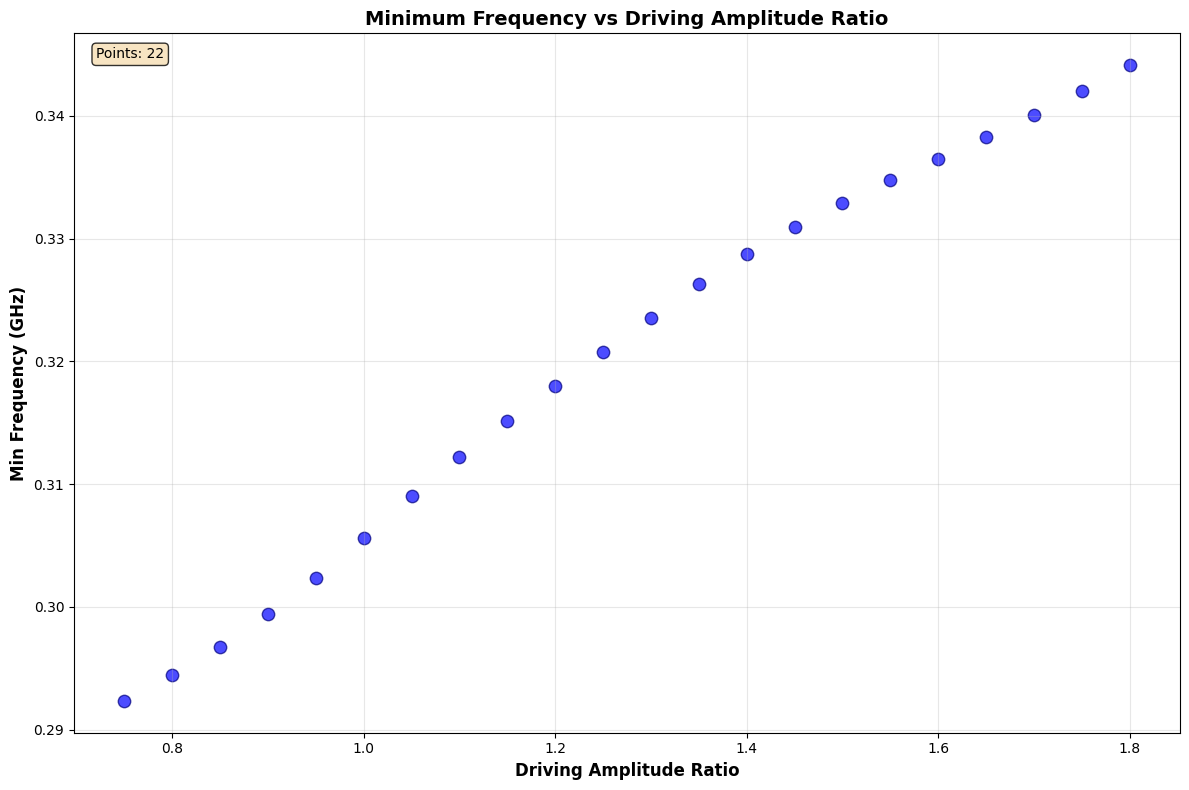


Data Summary:
  Number of data points: 22
  Driving amp ratio range: 0.750 - 1.800
  Min frequency range: 0.292330 - 0.344140 GHz


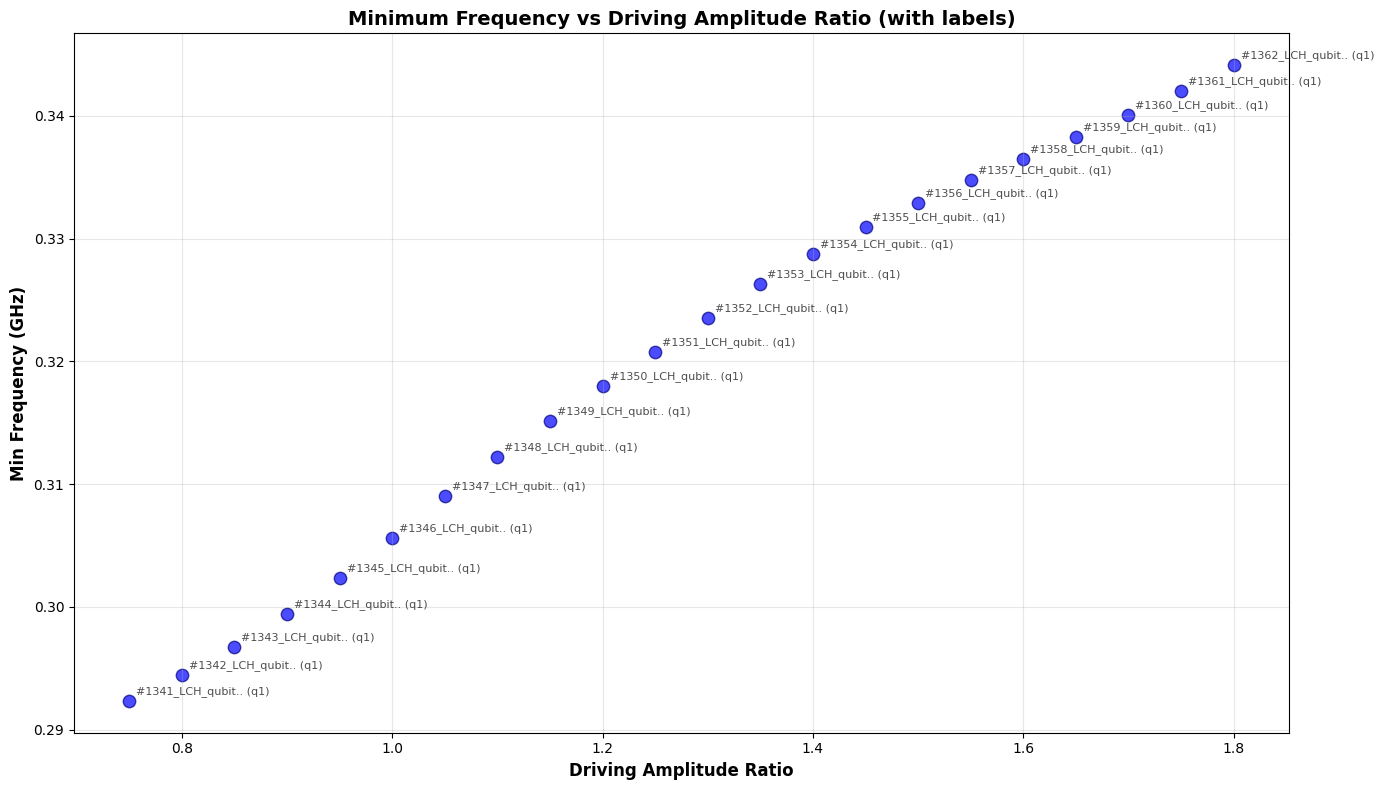

In [46]:
# Plot Min Frequency as function of Driving_amp_ratio
if 'results' in locals() and results:
    print("Creating plot: Min Frequency vs Driving Amplitude Ratio")
    
    # Extract data for plotting
    amp_ratios = []
    min_freqs_ghz = []
    folder_labels = []
    
    for result in results:
        if result['driving_amp_ratio'] is not None:
            amp_ratios.append(result['driving_amp_ratio'])
            min_freqs_ghz.append(result['min_freq_ghz'])
            # Create short folder labels for hover/annotation
            folder_short = result['folder'][:15] + '..' if len(result['folder']) > 15 else result['folder']
            folder_labels.append(f"{folder_short} ({result['qubit']})")
    
    if amp_ratios:
        # Create the plot
        plt.figure(figsize=(12, 8))
        scatter = plt.scatter(amp_ratios, min_freqs_ghz, s=80, alpha=0.7, c='blue', edgecolors='navy')
        
        # Formatting
        plt.xlabel('Driving Amplitude Ratio', fontsize=12, fontweight='bold')
        plt.ylabel('Min Frequency (GHz)', fontsize=12, fontweight='bold')
        plt.title('Minimum Frequency vs Driving Amplitude Ratio', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        
        # Add statistics text
        stats_text = f'Points: {len(amp_ratios)}'
        plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
        
        # Print data summary
        print(f"\nData Summary:")
        print(f"  Number of data points: {len(amp_ratios)}")
        print(f"  Driving amp ratio range: {min(amp_ratios):.3f} - {max(amp_ratios):.3f}")
        print(f"  Min frequency range: {min(min_freqs_ghz):.6f} - {max(min_freqs_ghz):.6f} GHz")
        
        # Additional plot with annotations
        plt.figure(figsize=(14, 8))
        for i, (amp, freq, label) in enumerate(zip(amp_ratios, min_freqs_ghz, folder_labels)):
            plt.scatter(amp, freq, s=80, alpha=0.7, c='blue', edgecolors='navy')
            plt.annotate(label, (amp, freq), xytext=(5, 5), textcoords='offset points', 
                        fontsize=8, alpha=0.7)
        
        plt.xlabel('Driving Amplitude Ratio', fontsize=12, fontweight='bold')
        plt.ylabel('Min Frequency (GHz)', fontsize=12, fontweight='bold')
        plt.title('Minimum Frequency vs Driving Amplitude Ratio (with labels)', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
    else:
        print("No data points with valid driving_amp_ratio found for plotting.")
        
else:
    print("No results data available. Please run cell 5 first to extract data.")

Creating 2D pcolormesh: state_data vs driving_time at min frequencies
Using pre-stored data from 22 files for 2D visualization...
  File 1: #1341_LCH_qubit_parametric_drive_time_0_002902 - Min freq: 0.292330 GHz
  File 2: #1342_LCH_qubit_parametric_drive_time_1_004346 - Min freq: 0.294420 GHz
  File 3: #1343_LCH_qubit_parametric_drive_time_2_005829 - Min freq: 0.296740 GHz
  File 4: #1344_LCH_qubit_parametric_drive_time_3_011313 - Min freq: 0.299400 GHz
  File 5: #1345_LCH_qubit_parametric_drive_time_4_012757 - Min freq: 0.302320 GHz
  File 6: #1346_LCH_qubit_parametric_drive_time_5_014241 - Min freq: 0.305590 GHz
  File 7: #1347_LCH_qubit_parametric_drive_time_6_015725 - Min freq: 0.309040 GHz
  File 8: #1348_LCH_qubit_parametric_drive_time_7_021208 - Min freq: 0.312210 GHz
  File 9: #1349_LCH_qubit_parametric_drive_time_8_022652 - Min freq: 0.315170 GHz
  File 10: #1350_LCH_qubit_parametric_drive_time_9_024136 - Min freq: 0.317960 GHz
  File 11: #1351_LCH_qubit_parametric_drive_time_

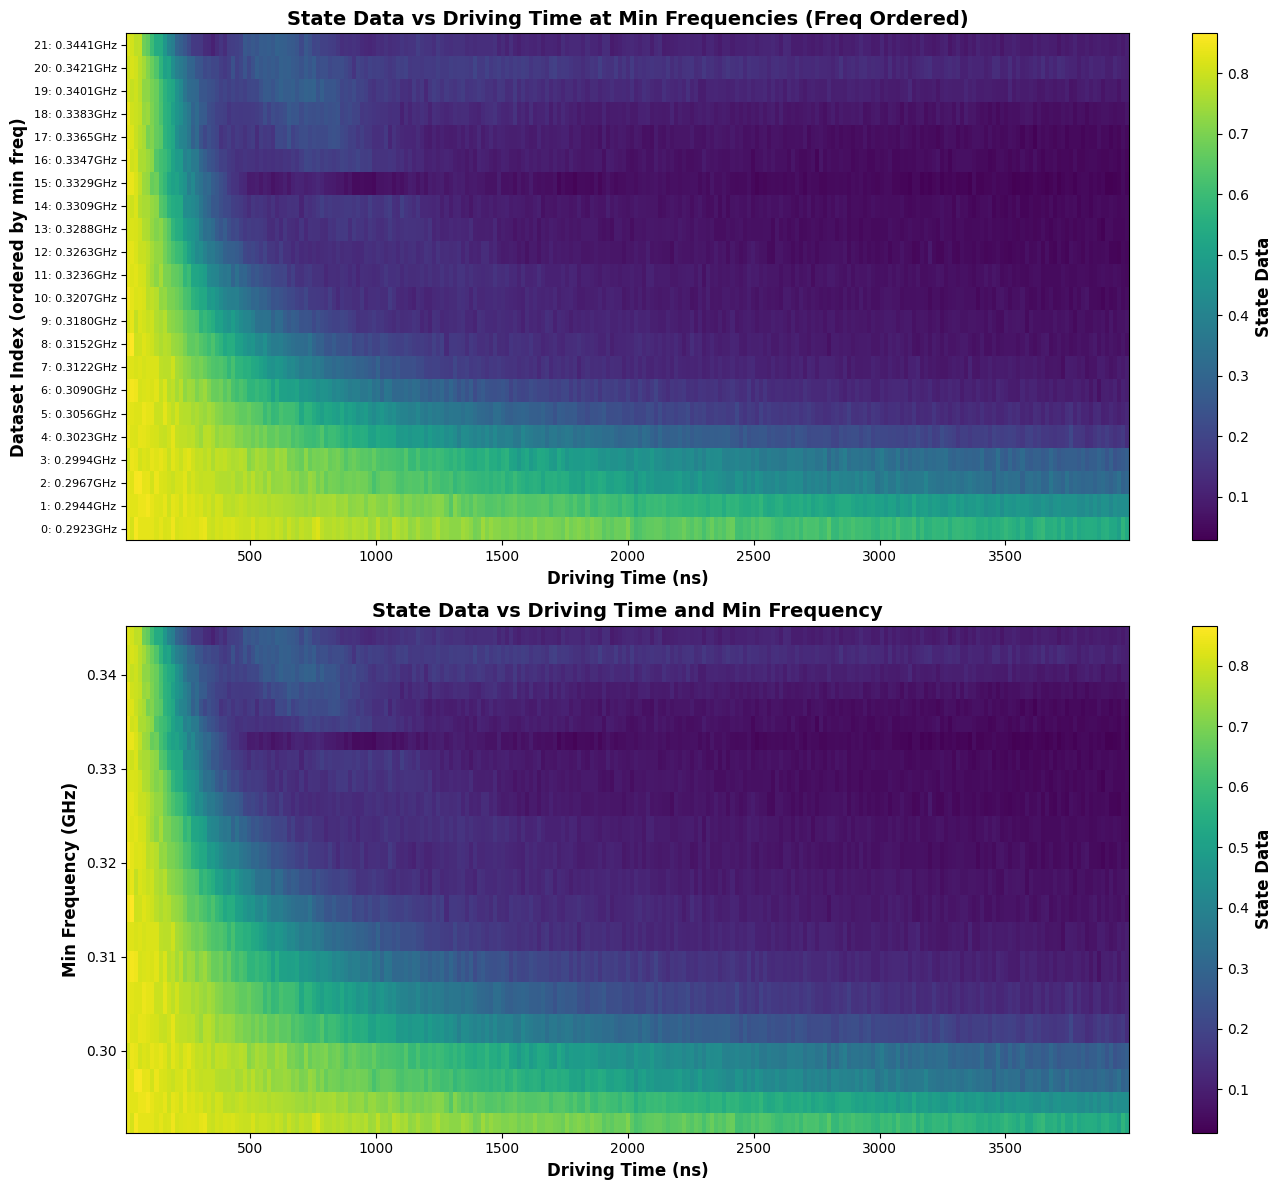


Plot Summary:
  Files plotted: 22
  Time range: 16.0 - 3984.0 ns
  Min frequency range: 0.292330 - 0.344140 GHz
  State data range: 0.028000 - 0.866000


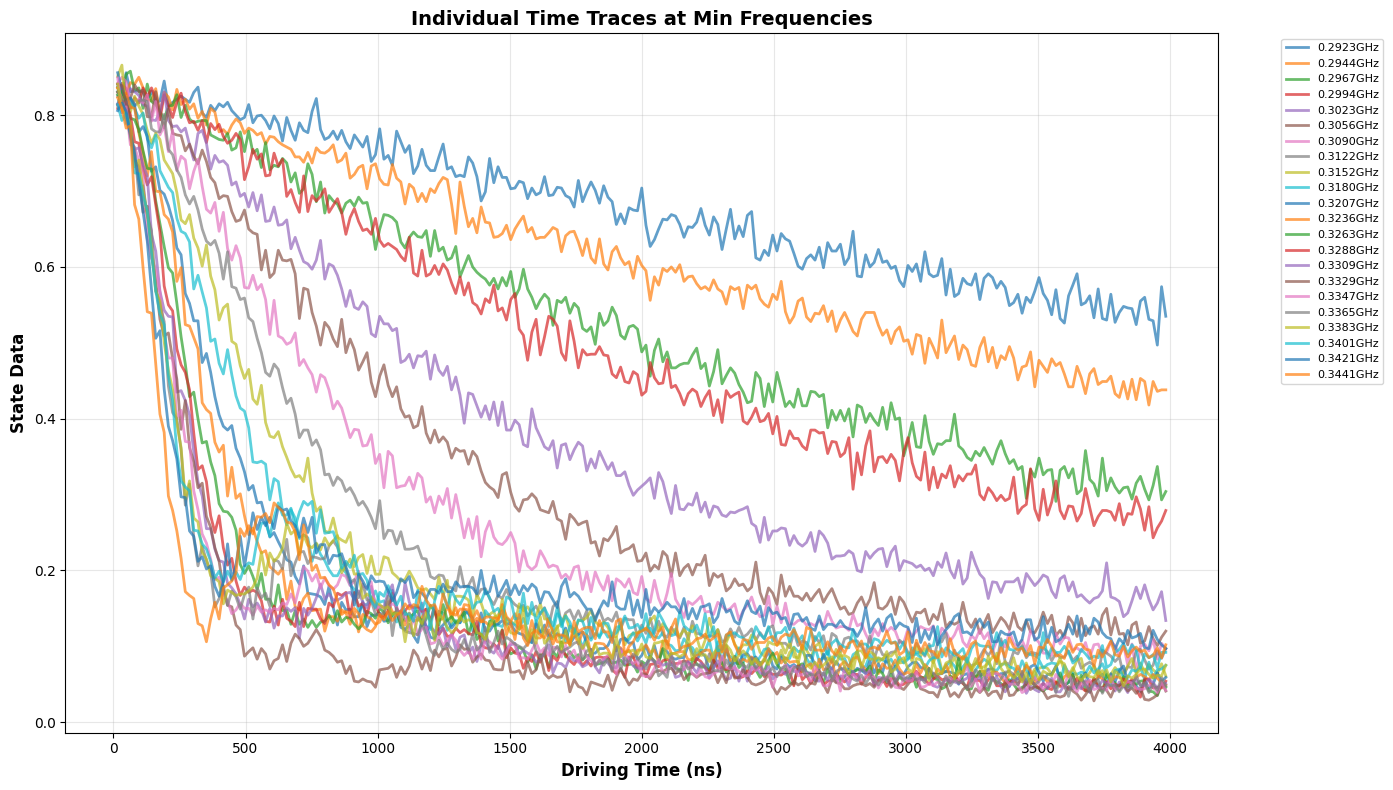

In [47]:
# Plot 2D pcolormesh: state_data vs driving_time at min_freq for each file
if 'results' in locals() and results:
    print("Creating 2D pcolormesh: state_data vs driving_time at min frequencies")
    
    # Prepare data for 2D plotting using pre-stored data
    valid_results = [r for r in results if r['driving_amp_ratio'] is not None and 'state_data_at_min_freq' in r]
    
    if valid_results:
        # Sort results by min frequency for better visualization
        valid_results.sort(key=lambda x: x['min_freq_ghz'])
        
        # Extract pre-stored data
        print(f"Using pre-stored data from {len(valid_results)} files for 2D visualization...")
        
        state_data_matrix = []
        labels = []
        min_freqs = []
        
        for idx, result in enumerate(valid_results):
            # Use pre-stored state data
            state_data_matrix.append(result['state_data_at_min_freq'])
            
            # Create label
            folder_short = result['folder'][:20] + '..' if len(result['folder']) > 22 else result['folder']
            label = f"{folder_short} ({result['min_freq_ghz']:.4f}GHz)"
            labels.append(label)
            min_freqs.append(result['min_freq_ghz'])
            
            print(f"  File {idx+1}: {result['folder']} - Min freq: {result['min_freq_ghz']:.6f} GHz")
        
        # Use driving time from first result (should be same for all)
        time_data_list = valid_results[0]['driving_time']
        
        # Convert to numpy array
        state_data_matrix = np.array(state_data_matrix)
        print(f"\nCreated matrix: {state_data_matrix.shape} (files × time_points)")
        
        # Create 2D pcolormesh plot
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
        
        # Plot 1: Ordered by min frequency
        Y_indices = np.arange(len(labels))
        X_time = time_data_list
        X_mesh, Y_mesh = np.meshgrid(X_time, Y_indices)
        
        im1 = ax1.pcolormesh(X_mesh, Y_mesh, state_data_matrix, cmap='viridis', shading='auto')
        ax1.set_xlabel('Driving Time (ns)', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Dataset Index (ordered by min freq)', fontsize=12, fontweight='bold')
        ax1.set_title('State Data vs Driving Time at Min Frequencies (Freq Ordered)', fontsize=14, fontweight='bold')
        
        # Set y-tick labels
        ax1.set_yticks(Y_indices)
        ax1.set_yticklabels([f"{i}: {f:.4f}GHz" for i, f in enumerate(min_freqs)], fontsize=8)
        
        # Add colorbar
        cbar1 = plt.colorbar(im1, ax=ax1)
        cbar1.set_label('State Data', fontsize=12, fontweight='bold')
        
        # Plot 2: Ordered by min frequency with frequency as Y-axis
        Y_freq = np.array(min_freqs)
        X_mesh_freq, Y_mesh_freq = np.meshgrid(X_time, Y_freq)
        
        im2 = ax2.pcolormesh(X_mesh_freq, Y_mesh_freq, state_data_matrix, cmap='viridis', shading='auto')
        ax2.set_xlabel('Driving Time (ns)', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Min Frequency (GHz)', fontsize=12, fontweight='bold')
        ax2.set_title('State Data vs Driving Time and Min Frequency', fontsize=14, fontweight='bold')
        
        # Add colorbar
        cbar2 = plt.colorbar(im2, ax=ax2)
        cbar2.set_label('State Data', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        # Print summary
        print(f"\nPlot Summary:")
        print(f"  Files plotted: {len(state_data_matrix)}")
        print(f"  Time range: {X_time[0]:.1f} - {X_time[-1]:.1f} ns")
        print(f"  Min frequency range: {min(min_freqs):.6f} - {max(min_freqs):.6f} GHz")
        print(f"  State data range: {np.min(state_data_matrix):.6f} - {np.max(state_data_matrix):.6f}")
        
        # Individual time traces plot
        plt.figure(figsize=(14, 8))
        for i, (state_trace, label, freq) in enumerate(zip(state_data_matrix, labels, min_freqs)):
            plt.plot(X_time, state_trace, label=f"{freq:.4f}GHz", alpha=0.7, linewidth=2)
        
        plt.xlabel('Driving Time (ns)', fontsize=12, fontweight='bold')
        plt.ylabel('State Data', fontsize=12, fontweight='bold')
        plt.title('Individual Time Traces at Min Frequencies', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
        plt.tight_layout()
        plt.show()
        
    else:
        print("No results with valid driving_amp_ratio and stored state data found for plotting.")
        
else:
    print("No results data available. Please run cell 5 first to extract data.")

In [48]:
# SVD and Hankel Matrix Analysis for each file - save plots to folders
from hankel_svd_analyzer import HankelSVDAnalyzer
import importlib
import hankel_svd_analyzer
importlib.reload(hankel_svd_analyzer)
from hankel_svd_analyzer import HankelSVDAnalyzer
import json

if 'results' in locals() and results:
    print("Performing SVD and Hankel Matrix analysis for each file...")
    print("=" * 60)
    
    # Prepare data for analysis using pre-stored data
    valid_results = [r for r in results if r['driving_amp_ratio'] is not None and 'state_data_at_min_freq' in r]
    
    if valid_results:
        print(f"Processing {len(valid_results)} files for SVD analysis...")
        
        for idx, result in enumerate(valid_results):
            try:
                print(f"\n=== Processing file {idx+1}/{len(valid_results)}: {result['folder']} ===")
                
                # Create output directory for this file
                output_dir = os.path.join(root_folder, result['folder'], 'svd_analysis')
                os.makedirs(output_dir, exist_ok=True)
                print(f"  Output directory: {output_dir}")
                
                # Extract data
                state_data = result['state_data_at_min_freq']
                driving_time = result['driving_time']
                min_freq_ghz = result['min_freq_ghz']
                folder_name = result['folder']
                qubit_name = result['qubit']
                
                print(f"  Min frequency: {min_freq_ghz:.6f} GHz")
                print(f"  Data points: {len(state_data)}")
                
                # Initialize the analyzer
                dt_ns = driving_time[1] - driving_time[0]  # Time step in nanoseconds
                analyzer = HankelSVDAnalyzer(dt_ns*1e-9)
                
                # Perform SVD analysis
                U, s, Vt = analyzer.analyze_signal(state_data)
                
                # Reconstruct signal using first few modes
                n_modes = min(5, len(s))
                reconstructed_signal = analyzer.reconstruct_signal(n_modes)
                
                # Get estimated n_components for vertical line annotations
                estimated_n_components = analyzer.estimate_n_components('energy', threshold=0.999)
                
                # Calculate x-axis limit based on 99% energy threshold
                cumulative_energy = np.cumsum(s**2) / np.sum(s**2)
                max_mode_99 = np.where(cumulative_energy < 0.995)[0]
                if len(max_mode_99) > 0:
                    x_limit_max = max_mode_99[-1] + 2  # +2 for better visualization
                else:
                    x_limit_max = min(10, len(s))  # fallback limit
                
                # Plot 1: SVD Reconstruction
                plt.figure(figsize=(10, 6))
                plt.plot(driving_time, state_data, 'b-', linewidth=2, label='Original')
                plt.plot(driving_time, reconstructed_signal, 'r--', linewidth=2, label=f'SVD Reconstruction ({n_modes} modes)')
                plt.xlabel('Driving Time (ns)')
                plt.ylabel('State')
                plt.title(f'SVD Reconstruction - {folder_name}\nQubit: {qubit_name} @ {min_freq_ghz:.6f} GHz')
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.savefig(os.path.join(output_dir, '01_svd_reconstruction.png'), dpi=300, bbox_inches='tight')
                plt.close()
                
                # Plot 2: Singular Values
                plt.figure(figsize=(10, 6))
                plt.semilogy(s, 'bo-', markersize=4, linewidth=2)
                plt.axvline(x=estimated_n_components-1, color='red', linestyle='--', alpha=0.7, 
                           label=f'Estimated n_comp: {estimated_n_components}')
                plt.xlim(-0.5, x_limit_max - 0.5)
                plt.xlabel('Mode Number')
                plt.ylabel('Singular Value')
                plt.title(f'SVD Spectrum - {folder_name}\nQubit: {qubit_name} @ {min_freq_ghz:.6f} GHz')
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.savefig(os.path.join(output_dir, '02_singular_values.png'), dpi=300, bbox_inches='tight')
                plt.close()
                
                # Plot 3: SVD Modes
                plt.figure(figsize=(10, 6))
                n_modes_plot = n_modes
                time_hankel = driving_time[:U.shape[0]]  # Time for Hankel matrix rows
                
                for mode in range(n_modes_plot):
                    plt.plot(time_hankel, U[:, mode], label=f'Mode {mode+1} (σ={s[mode]:.3f})', linewidth=1.5)
                
                plt.xlabel('Time (ns)')
                plt.ylabel('Amplitude')
                plt.title(f'SVD Modes - {folder_name}\nQubit: {qubit_name} @ {min_freq_ghz:.6f} GHz')
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.savefig(os.path.join(output_dir, '03_svd_modes.png'), dpi=300, bbox_inches='tight')
                plt.close()
                
                # Plot 4: Singular Value Differences
                plt.figure(figsize=(10, 6))
                if len(s) > 1:
                    # Calculate log differences: log(s_i) - log(s_i+1)
                    log_s_diff = np.log(s[:-1]) - np.log(s[1:])
                    x_indices = np.arange(len(log_s_diff)) + 0.5
                    
                    plt.plot(x_indices, log_s_diff, 'go-', markersize=6, linewidth=2)
                    plt.axvline(x=estimated_n_components-0.5, color='red', linestyle='--', alpha=0.7, 
                               label=f'Estimated n_comp: {estimated_n_components}')
                    plt.xlim(0, x_limit_max - 0.5)
                    plt.xlabel('Singular Value Index + 0.5')
                    plt.ylabel('log(s_i) - log(s_{i+1})')
                    plt.title(f'Singular Value Log Differences - {folder_name}\nQubit: {qubit_name} @ {min_freq_ghz:.6f} GHz')
                    plt.grid(True, alpha=0.3)
                    
                    # Add annotation for interpretation
                    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5, label='Zero difference')
                    plt.legend()
                else:
                    plt.text(0.5, 0.5, 'Not enough singular values\nfor difference calculation', 
                            transform=plt.gca().transAxes, ha='center', va='center', fontsize=12)
                    plt.xlabel('Singular Value Index + 0.5')
                    plt.ylabel('log(s_i) - log(s_{i+1})')
                    plt.title(f'Singular Value Log Differences - {folder_name}\nQubit: {qubit_name} @ {min_freq_ghz:.6f} GHz')
                    plt.grid(True, alpha=0.3)
                
                plt.tight_layout()
                plt.savefig(os.path.join(output_dir, '04_singular_value_differences.png'), dpi=300, bbox_inches='tight')
                plt.close()
                
                # Plot 5: Complementary Cumulative Energy
                plt.figure(figsize=(10, 6))
                if len(s) > 0:
                    # Calculate complementary cumulative energy: 1 - sum(s[:i]**2) / sum(s**2)
                    total_energy = np.sum(s**2)
                    i_values = np.arange(1, len(s) + 1)
                    complementary_energy = []
                    
                    for i in i_values:
                        cumulative_energy = np.sum(s[:i]**2) / total_energy
                        complementary_energy.append(1 - cumulative_energy)
                    
                    plt.semilogy(i_values, complementary_energy, 'mo-', markersize=6, linewidth=2)
                    plt.axvline(x=estimated_n_components, color='red', linestyle='--', alpha=0.7, 
                               label=f'Estimated n_comp: {estimated_n_components}')
                    plt.xlim(0.5, x_limit_max + 0.5)
                    plt.ylim(1e-3, 1)
                    plt.xlabel('Number of Components (i)')
                    plt.ylabel('1 - Σs²[:i] / Σs²')
                    plt.title(f'Complementary Cumulative Energy - {folder_name}\nQubit: {qubit_name} @ {min_freq_ghz:.6f} GHz')
                    plt.grid(True, alpha=0.3)
                    
                    # Add horizontal lines for reference
                    plt.axhline(y=0.1, color='gray', linestyle='--', alpha=0.5, label='10% remaining')
                    plt.axhline(y=0.01, color='orange', linestyle='--', alpha=0.5, label='1% remaining')
                    plt.legend()
                else:
                    plt.text(0.5, 0.5, 'No singular values available', 
                            transform=plt.gca().transAxes, ha='center', va='center', fontsize=12)
                    plt.xlabel('Number of Components (i)')
                    plt.ylabel('1 - Σs²[:i] / Σs²')
                    plt.title(f'Complementary Cumulative Energy - {folder_name}\nQubit: {qubit_name} @ {min_freq_ghz:.6f} GHz')
                    plt.grid(True, alpha=0.3)
                
                plt.tight_layout()
                plt.savefig(os.path.join(output_dir, '05_complementary_cumulative_energy.png'), dpi=300, bbox_inches='tight')
                plt.close()
                
                # === Extract Complex Poles ===
                # Sweep analysis with n_component_max = 10
                n_component_max = 10
                sweep_results = analyzer.sweep_components(min(n_component_max, len(s)))
                
                # Plot z poles as function of n_components
                if sweep_results:
                    # Collect z poles for plotting
                    n_components_list = []
                    z_real_list = []
                    z_imag_list = []
                    
                    for n_comp, poles in sweep_results.items():
                        for pole in poles:
                            n_components_list.append(n_comp)
                            z_real_list.append(pole['z_pole'].real)
                            z_imag_list.append(pole['z_pole'].imag)
                    
                    if n_components_list:  # Only plot if we have data
                        # Plot Real and Imaginary parts
                        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
                        
                        # Real part
                        ax1.scatter(n_components_list, z_real_list, alpha=0.2, s=50)
                        ax1.set_xlabel('Number of Components')
                        ax1.set_ylabel('Real(z)')
                        ax1.set_title(f'Real Part of z Poles - {folder_name}\nQubit: {qubit_name} @ {min_freq_ghz:.6f} GHz')
                        ax1.grid(True, alpha=0.3)
                        ax1.set_xticks(range(1, min(n_component_max, len(s))+1))
                        
                        # Imaginary part
                        ax2.scatter(n_components_list, z_imag_list, alpha=0.2, s=50)
                        ax2.set_xlabel('Number of Components')
                        ax2.set_ylabel('Imag(z)')
                        ax2.set_title(f'Imaginary Part of z Poles - {folder_name}\nQubit: {qubit_name} @ {min_freq_ghz:.6f} GHz')
                        ax2.grid(True, alpha=0.3)
                        ax2.set_xticks(range(1, min(n_component_max, len(s))+1))
                        
                        plt.tight_layout()
                        plt.savefig(os.path.join(output_dir, '06_complex_poles.png'), dpi=300, bbox_inches='tight')
                        plt.close()
                
                # Create analysis summary as JSON
                summary_data = {
                    'estimated_n_components': int(estimated_n_components),  # Convert numpy int to Python int
                    'sweep_results': {}
                }
                
                # Add pole information in JSON format
                if sweep_results:
                    for n_comp, poles in sweep_results.items():
                        summary_data['sweep_results'][str(n_comp)] = []
                        for pole in poles:
                            pole_data = {
                                'z_pole_real': float(pole["z_pole"].real),
                                'z_pole_imag': float(pole["z_pole"].imag), 
                                'time_constant': float(pole['time_constant']) if np.isfinite(pole['time_constant']) else None,
                                'freq_hz': float(pole['freq_hz'])
                            }
                            summary_data['sweep_results'][str(n_comp)].append(pole_data)
                
                # Save summary as JSON file
                with open(os.path.join(output_dir, 'analysis_summary.txt'), 'w') as f:
                    json.dump(summary_data, f, indent=2)
                
                print(f"  ✅ Analysis complete! Saved {6} plots + summary to {output_dir}")
                print(f"     Estimated n_components: {estimated_n_components}")
                
            except Exception as e:
                print(f"  ❌ ERROR analyzing {result['folder']}: {e}")
                continue
        
        print(f"\n{'='*60}")
        print(f"SVD/Hankel analysis complete for {len(valid_results)} files!")
        print("Generated files for each dataset:")
        print("  01_svd_reconstruction.png")
        print("  02_singular_values.png") 
        print("  03_svd_modes.png")
        print("  04_singular_value_differences.png")
        print("  05_complementary_cumulative_energy.png")
        print("  06_complex_poles.png")
        print("  analysis_summary.txt")
        
    else:
        print("No results with valid driving_amp_ratio and stored state data found for analysis.")
        
else:
    print("No results data available. Please run cell 5 first to extract data.")

Performing SVD and Hankel Matrix analysis for each file...
Processing 22 files for SVD analysis...

=== Processing file 1/22: #1341_LCH_qubit_parametric_drive_time_0_002902 ===
  Output directory: D:\data\EP\Parametric_drive\QtoR\20260202\#1341_LCH_qubit_parametric_drive_time_0_002902\svd_analysis
  Min frequency: 0.292330 GHz
  Data points: 249
  ✅ Analysis complete! Saved 6 plots + summary to D:\data\EP\Parametric_drive\QtoR\20260202\#1341_LCH_qubit_parametric_drive_time_0_002902\svd_analysis
     Estimated n_components: 1

=== Processing file 2/22: #1342_LCH_qubit_parametric_drive_time_1_004346 ===
  Output directory: D:\data\EP\Parametric_drive\QtoR\20260202\#1342_LCH_qubit_parametric_drive_time_1_004346\svd_analysis
  Min frequency: 0.294420 GHz
  Data points: 249
  ✅ Analysis complete! Saved 6 plots + summary to D:\data\EP\Parametric_drive\QtoR\20260202\#1342_LCH_qubit_parametric_drive_time_1_004346\svd_analysis
     Estimated n_components: 1

=== Processing file 3/22: #1343_LCH_

Reading analysis_summary.txt files and plotting pole data vs amp_ratio...
  ✅ #1341_LCH_qubit_parametric_drive_time_0_002902: n_comp=1, 1 poles
  ✅ #1342_LCH_qubit_parametric_drive_time_1_004346: n_comp=1, 1 poles
  ✅ #1343_LCH_qubit_parametric_drive_time_2_005829: n_comp=1, 1 poles
  ✅ #1344_LCH_qubit_parametric_drive_time_3_011313: n_comp=1, 1 poles
  ✅ #1345_LCH_qubit_parametric_drive_time_4_012757: n_comp=2, 2 poles
  ✅ #1346_LCH_qubit_parametric_drive_time_5_014241: n_comp=2, 2 poles
  ✅ #1347_LCH_qubit_parametric_drive_time_6_015725: n_comp=2, 2 poles
  ✅ #1348_LCH_qubit_parametric_drive_time_7_021208: n_comp=3, 2 poles
  ✅ #1349_LCH_qubit_parametric_drive_time_8_022652: n_comp=3, 2 poles
  ✅ #1350_LCH_qubit_parametric_drive_time_9_024136: n_comp=3, 2 poles
  ✅ #1351_LCH_qubit_parametric_drive_time_10_025620: n_comp=3, 2 poles
  ✅ #1352_LCH_qubit_parametric_drive_time_11_031104: n_comp=3, 2 poles
  ✅ #1353_LCH_qubit_parametric_drive_time_12_032548: n_comp=2, 2 poles
  ✅ #1354_LCH

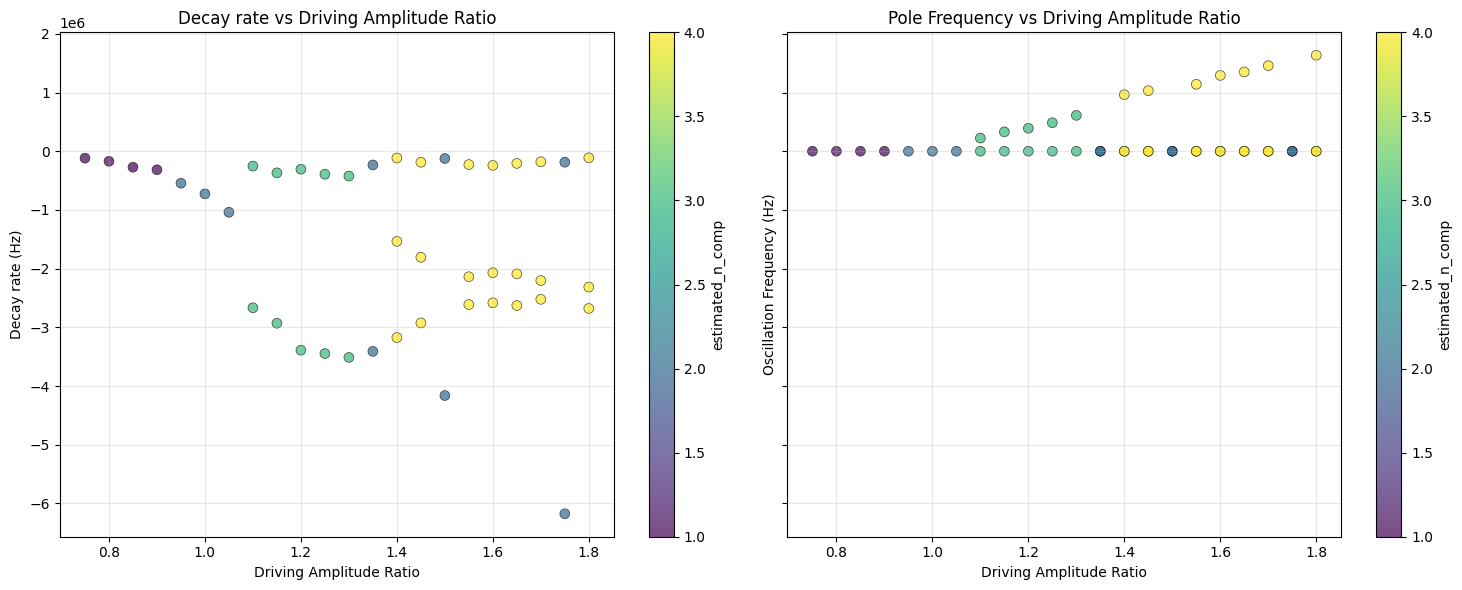


POLE ANALYSIS SUMMARY
Total pole data points: 44
Unique files: 22
Amp ratio range: 0.750 - 1.800
1/time_constant range: -6.18e+06 - -1.11e+05 (1/s)
Frequency range: 0.00e+00 - 1.63e+06 Hz
estimated_n_components range: 1 - 4


In [49]:
# Plot pole analysis data (1/time_constant and freq_hz) vs driving_amp_ratio
if 'results' in locals() and results:
    print("Reading analysis_summary.txt files and plotting pole data vs amp_ratio...")
    print("=" * 70)
    
    # Prepare data for plotting
    valid_results = [r for r in results if r['driving_amp_ratio'] is not None]
    
    if valid_results:
        plot_data = []
        
        for result in valid_results:
            summary_file = os.path.join(root_folder, result['folder'], 'svd_analysis', 'analysis_summary.txt')
            
            if os.path.exists(summary_file):
                try:
                    with open(summary_file, 'r') as f:
                        summary_data = json.load(f)
                    
                    # Get estimated_n_components for this file
                    estimated_n_comp = summary_data.get('estimated_n_components')
                    
                    # Only extract pole data for n_components == estimated_n_components
                    if estimated_n_comp is not None and str(estimated_n_comp) in summary_data.get('sweep_results', {}):
                        poles = summary_data['sweep_results'][str(estimated_n_comp)]
                        
                        for pole_idx, pole in enumerate(poles):
                            if pole['time_constant'] is not None:  # Only valid time constants
                                plot_data.append({
                                    'folder': result['folder'],
                                    'amp_ratio': result['driving_amp_ratio'],
                                    'estimated_n_components': estimated_n_comp,
                                    'pole_idx': pole_idx,
                                    'time_constant': pole['time_constant'],
                                    'inv_time_constant': 1.0 / pole['time_constant'],
                                    'freq_hz': pole['freq_hz'],
                                    'z_pole_real': pole['z_pole_real'],
                                    'z_pole_imag': pole['z_pole_imag']
                                })
                        
                        print(f"  ✅ {result['folder']}: n_comp={estimated_n_comp}, {len(poles)} poles")
                    else:
                        print(f"  ⚠️  {result['folder']}: No valid estimated_n_components or pole data")
                    
                except Exception as e:
                    print(f"  ❌ ERROR reading {result['folder']}: {e}")
                    continue
            else:
                print(f"  ⚠️  Missing analysis file: {result['folder']}")
        
        if plot_data:
            print(f"\nCollected {len(plot_data)} pole data points from {len(set([d['folder'] for d in plot_data]))} files")
            
            # Create simplified plots
            fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
            
            # Extract data arrays for plotting
            amp_ratios = [d['amp_ratio'] for d in plot_data]
            inv_time_constants = [-d['inv_time_constant'] for d in plot_data]
            freq_hz_values = [d['freq_hz'] for d in plot_data]
            n_components_values = [d['estimated_n_components'] for d in plot_data]
            
            # Plot 1: 1/time_constant vs amp_ratio (linear scale)
            scatter1 = axes[0].scatter(amp_ratios, inv_time_constants, 
                                     c=n_components_values, cmap='viridis', 
                                     alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
            axes[0].set_xlabel('Driving Amplitude Ratio')
            axes[0].set_ylabel('Decay rate (Hz)')
            axes[0].set_title('Decay rate vs Driving Amplitude Ratio')
            axes[0].grid(True, alpha=0.3)
            cbar1 = plt.colorbar(scatter1, ax=axes[0])
            cbar1.set_label('estimated_n_comp')
            
            # Plot 2: freq_hz vs amp_ratio (linear scale)
            scatter2 = axes[1].scatter(amp_ratios, freq_hz_values, 
                                     c=n_components_values, cmap='viridis', 
                                     alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
            axes[1].set_xlabel('Driving Amplitude Ratio')
            axes[1].set_ylabel('Oscillation Frequency (Hz)')
            axes[1].set_title('Pole Frequency vs Driving Amplitude Ratio')
            axes[1].grid(True, alpha=0.3)
            cbar2 = plt.colorbar(scatter2, ax=axes[1])
            cbar2.set_label('estimated_n_comp')
            
            plt.tight_layout()
            plt.show()
            
            # Summary statistics
            print(f"\n{'='*50}")
            print("POLE ANALYSIS SUMMARY")
            print(f"{'='*50}")
            print(f"Total pole data points: {len(plot_data)}")
            print(f"Unique files: {len(set([d['folder'] for d in plot_data]))}")
            print(f"Amp ratio range: {min(amp_ratios):.3f} - {max(amp_ratios):.3f}")
            print(f"1/time_constant range: {min(inv_time_constants):.2e} - {max(inv_time_constants):.2e} (1/s)")
            print(f"Frequency range: {min(freq_hz_values):.2e} - {max(freq_hz_values):.2e} Hz")
            print(f"estimated_n_components range: {min(n_components_values)} - {max(n_components_values)}")
            
        else:
            print("No valid pole data found for plotting.")
            
    else:
        print("No results with valid driving_amp_ratio found.")
        
else:
    print("No results data available. Please run cell 5 first to extract data.")